# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("loan_data.csv")

# Change 0 and 1 into labels
df["loan_status_label"] = df["loan_status"].map({0: "Denied", 1: "Accepted"})

accepted = df[df["loan_status"] == 1]
denied = df[df["loan_status"] == 0]

print(df.head())
print(df.shape)
print(df["loan_status_label"].value_counts())

   person_age person_gender person_education  person_income  person_emp_exp  \
0          71          male        Associate   46817.176426               3   
1          34          male      High School   79093.494008              17   
2          80          male        Associate   67819.614431              20   
3          40        female        Associate   49599.861220               0   
4          43          male        Doctorate   99833.900180               8   

  person_home_ownership     loan_amnt loan_intent  loan_int_rate  \
0                  RENT  11567.737650     MEDICAL      10.351469   
1                   OWN   9519.674498     MEDICAL      11.168902   
2                   OWN  16226.604002    PERSONAL      12.293112   
3                  RENT  15641.221708     VENTURE      10.327926   
4                   OWN  12727.942517   EDUCATION       9.338069   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0             0.247083                          

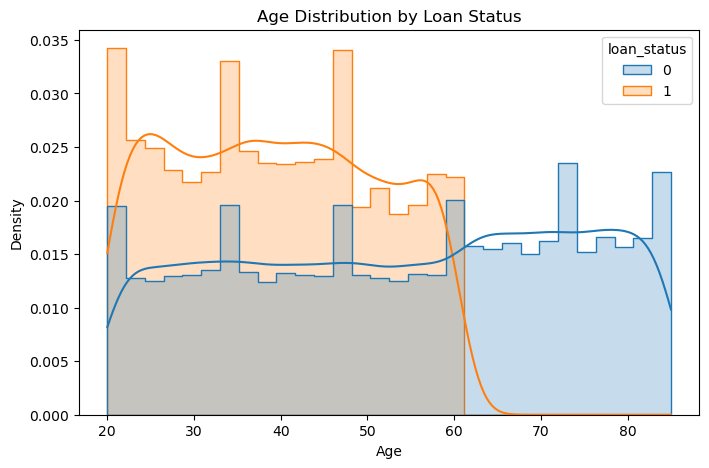

Accepted median age: 39.0
Denied median age: 55.0


In [33]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="person_age",
    hue="loan_status",
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Age Distribution by Loan Status")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

print("Accepted median age:", accepted["person_age"].median())
print("Denied median age:", denied["person_age"].median())

This graph shows that people who were accepted for a loan tend to be younger than people who were denied. Most of the accepted applicants are grouped more in the younger to middle-age range, while denied applicants stretch more into older ages. This makes age look like it may be connected to the model’s decision, which could be a problem since age was one of the discrimination concerns.

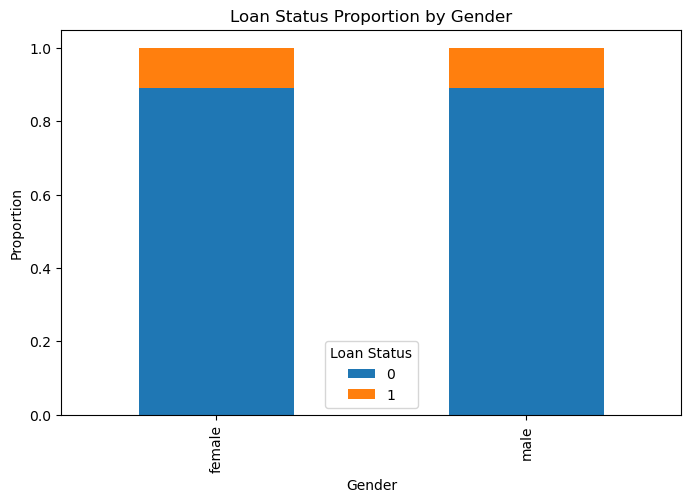

person_gender
female    11.03
male      10.77
Name: loan_status, dtype: float64


In [31]:
gender_status = pd.crosstab(df["person_gender"], df["loan_status"], normalize="index")
gender_status.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Loan Status Proportion by Gender")
plt.xlabel("Gender")
plt.ylabel("Proportion")
plt.legend(title="Loan Status")
plt.show()

print((df.groupby("person_gender")["loan_status"].mean() * 100).round(2))

This graph shows that males and females have almost the exact same acceptance and denial rates. The bars are nearly identical, which means gender does not seem to have much effect on whether a loan is accepted or denied. Based on this graph, sex does not look like a major factor in the model.

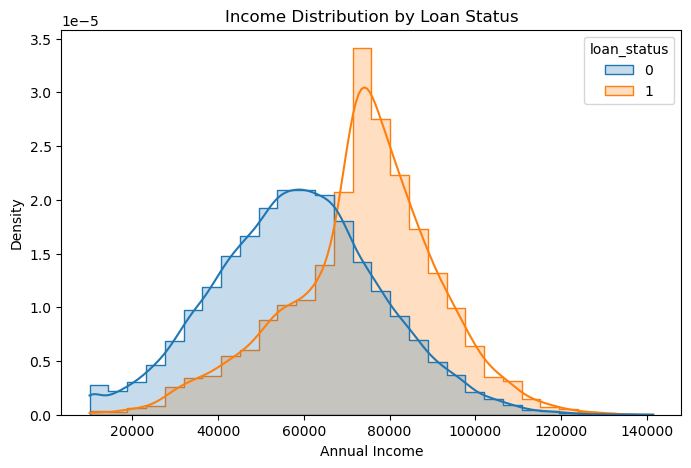

Accepted median income: 74654.58085498522
Denied median income: 58519.75389204194


In [32]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="person_income",
    hue="loan_status",
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Income Distribution by Loan Status")
plt.xlabel("Annual Income")
plt.ylabel("Density")
plt.show()

print("Accepted median income:", accepted["person_income"].median())
print("Denied median income:", denied["person_income"].median())

This graph shows that accepted applicants usually have higher incomes than denied applicants. The accepted group is centered more around higher income values, while the denied group is more concentrated at lower income levels. This suggests income is an important feature in the model because people with more income may look more able to repay a loan.

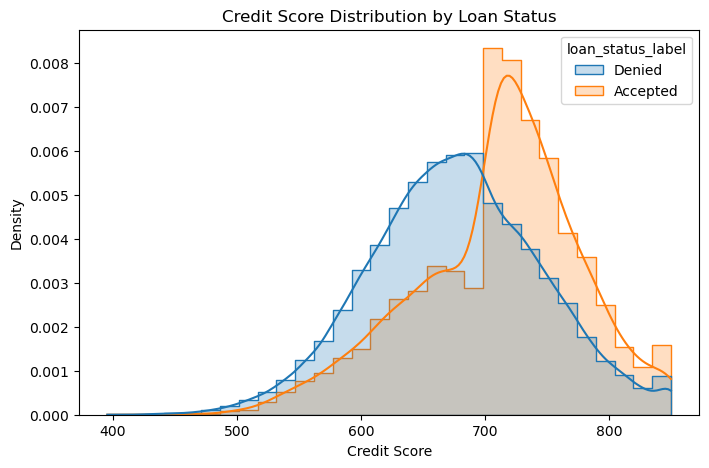

Accepted median credit score: 717.2075929956202
Denied median credit score: 675.6426854099473


In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="credit_score",
    hue="loan_status_label",
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Credit Score Distribution by Loan Status")
plt.xlabel("Credit Score")
plt.ylabel("Density")
plt.show()

print("Accepted median credit score:", accepted["credit_score"].median())
print("Denied median credit score:", denied["credit_score"].median())

This graph shows one of the clearest differences between accepted and denied applicants. Accepted applicants are grouped around higher credit scores, while denied applicants are more common at lower credit scores. This makes credit score look like one of the strongest drivers of the loan decision.

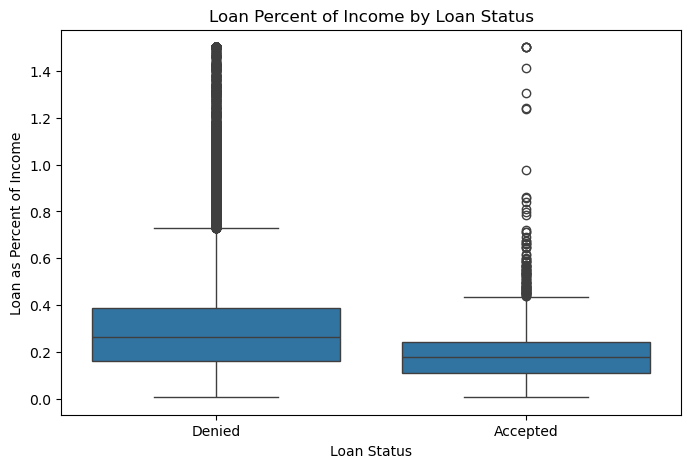

Accepted median loan percent income: 0.1814378353215441
Denied median loan percent income: 0.2632212959304583


In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="loan_status_label", y="loan_percent_income")
plt.title("Loan Percent of Income by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan as Percent of Income")
plt.show()

print("Accepted median loan percent income:", accepted["loan_percent_income"].median())
print("Denied median loan percent income:", denied["loan_percent_income"].median())

This boxplot shows that accepted applicants usually have a lower loan percent of income than denied applicants. In other words, accepted people are asking for loans that take up less of their yearly income. That makes this feature look very important because the model seems more likely to accept loans that look easier for the applicant to afford.

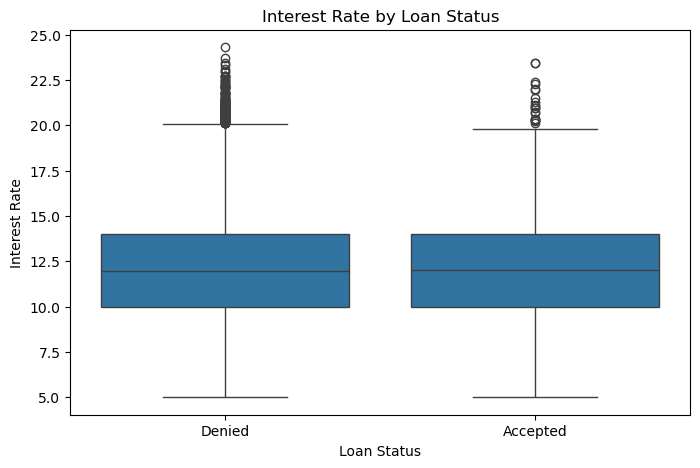

Accepted median interest rate: 12.01810222706299
Denied median interest rate: 11.982008201665828


In [29]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="loan_status_label", y="loan_int_rate")
plt.title("Interest Rate by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Interest Rate")
plt.show()

print("Accepted median interest rate:", accepted["loan_int_rate"].median())
print("Denied median interest rate:", denied["loan_int_rate"].median())

This graph shows that accepted and denied applicants have very similar interest rates. The medians and the overall spread are almost the same, and the boxes overlap a lot. This suggests interest rate does not seem to play a big role in whether the model accepts or denies a loan.

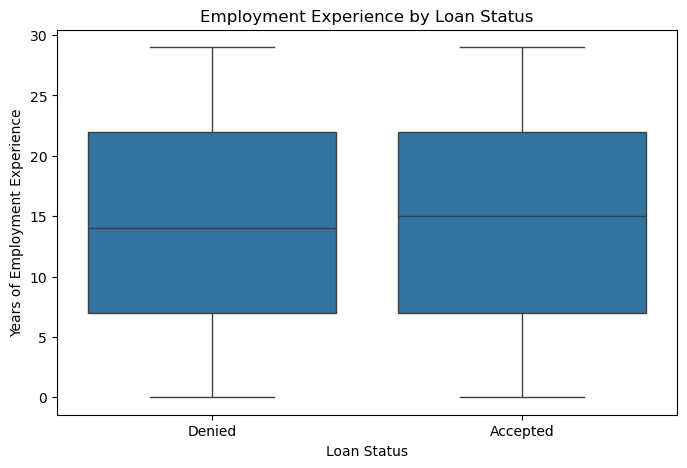

Accepted median employment experience: 15.0
Denied median employment experience: 14.0


In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="loan_status_label", y="person_emp_exp")
plt.title("Employment Experience by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Years of Employment Experience")
plt.show()

print("Accepted median employment experience:", accepted["person_emp_exp"].median())
print("Denied median employment experience:", denied["person_emp_exp"].median())

This graph also shows a lot of overlap between accepted and denied applicants. The medians are close, and both groups have a very similar spread of years of experience. That means employment experience does not seem to strongly affect the model compared to features like credit score, income, or loan percent of income.

The person most likely to be accepted for a loan would be a younger applicant with a high income, a strong credit score, and a low loan percent of income. The applicant could be either male or female since gender does not seem to make much difference in the results. This type of person matches the patterns in the graphs because accepted applicants were generally younger, earned more money, had better credit scores, and requested loans that took up less of their income.